# Week 9 — Deep Neural Network Architectures & Advanced Training

## Day 1 — Session 2: Vanishing and Exploding Gradients

**Main theme:** *What happens to the gradient as it travels backward through many layers?*

### Central Question

> **If backpropagation sends the gradient backward through a deep network, what happens to the gradient after passing through many layers?**

The answer leads to two fundamental problems:

* **Vanishing gradients:** the gradient becomes extremely small.
* **Exploding gradients:** the gradient becomes extremely large.

The goal of this session is **not** to memorize these terms. Students should develop the intuition that:

> **Backpropagation repeatedly multiplies gradient signals. Small factors can make the signal disappear; large factors can make it explode.**

---

# 1. Warm-up: What Did We Learn About Gradients?

> What does a large gradient mean?

answer:

> The Loss is very sensitive to the parameter.


> What does a very small gradient mean?

answer:

> Changing the parameter has very little immediate effect on the Loss.

---

# 2. The New Question: How Does the Gradient Reach Earlier Layers?

Consider a simple network:

```text
Input
  ↓
Layer 1
  ↓
Layer 2
  ↓
Layer 3
  ↓
Output
  ↓
Loss
```

During backpropagation:

```text
Loss
  ↓
Gradient
  ↓
Layer 3
  ↓
Layer 2
  ↓
Layer 1
```

The gradient has to travel through every layer.

The important question is:

> **Does the gradient stay the same while traveling backward?**

No.

---

# 3. A Numerical Chain-Rule Example

Consider:

$$
y = f_3(f_2(f_1(x)))
$$

Suppose the derivatives at the current point are:

$$
\frac{\partial f_3}{\partial f_2}=0.5
$$

$$
\frac{\partial f_2}{\partial f_1}=0.5
$$

$$
\frac{\partial f_1}{\partial x}=0.5
$$

By the Chain Rule:

$$
\frac{\partial y}{\partial x}=
\frac{\partial y}{\partial f_3}
\frac{\partial f_3}{\partial f_2}
\frac{\partial f_2}{\partial f_1}
\frac{\partial f_1}{\partial x}
$$

Ignoring the first factor for the moment:

$$
0.5 \times 0.5 \times 0.5=
0.125
$$

With only three multiplications:

$$
0.5^3=0.125
$$

Now imagine 10 layers:

$$
0.5^{10}
\approx
0.00098
$$

And 50 layers:

$$
0.5^{50}
\approx
8.88\times10^{-16}
$$

The signal has almost disappeared.

---

# 4. Core Intuition: Repeated Multiplication — 15 min

This is the most important numerical experiment of the session.

Run:

```python
import numpy as np
import matplotlib.pyplot as plt

factors = [0.5, 0.9, 1.0, 1.1, 1.5]

layers = np.arange(0, 31)

plt.figure(figsize=(9, 5))

for factor in factors:
    gradient_signal = factor ** layers

    plt.plot(
        layers,
        gradient_signal,
        marker="o",
        markersize=3,
        label=f"factor = {factor}"
    )

plt.yscale("log")

plt.xlabel("Number of layers")
plt.ylabel("Gradient magnitude")
plt.title("What Happens When Gradients Are Repeatedly Multiplied?")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()
```

### Questions

Look at the curves and answer:

1. What happens when the factor is $0.5$?
2. What happens when the factor is $0.9$?
3. What happens when the factor is $1.0$?
4. What happens when the factor is $1.1$?
5. What happens when the factor is $1.5$?

### Expected Observation

If:

$$
0<c<1
$$

then:

$$
c^L\rightarrow0
$$

as the number of layers $L$ increases.

If:

$$
c>1
$$

then:

$$
c^L\rightarrow\infty
$$

as $L$ increases.

Therefore:

```text
Repeated multiplication
        │
        ├── factor < 1 ──→ Vanishing
        │
        ├── factor ≈ 1 ──→ Stable
        │
        └── factor > 1 ──→ Exploding
```

---

# 5. Connecting This to Backpropagation

For a deep network:

$$
\frac{\partial L}{\partial w^{(1)}}
$$

depends on a chain of derivatives from later layers.

Conceptually:

$$
\frac{\partial L}{\partial w^{(1)}}
\approx
\frac{\partial L}{\partial w^{(L)}}
\times
A_L
\times
A_{L-1}
\times
\cdots
\times
A_2
$$

where each $A_i$ represents the local derivative contributed by a layer.

The important point is:

> **The gradient reaching an early layer is the result of many multiplicative factors.**

This is why depth can create a problem.

---

# 6. Why Sigmoid Can Cause Vanishing Gradients

The sigmoid function is:

$$
\sigma(x)=\frac{1}{1+e^{-x}}
$$

Its derivative is:

$$
\sigma'(x)=\sigma(x)(1-\sigma(x))
$$

The maximum derivative occurs at $x=0$:

$$
\sigma'(0)=0.25
$$

So:

$$
0 < \sigma'(x)\leq0.25
$$

This is extremely important.

If many sigmoid layers are stacked together, we repeatedly multiply by numbers no larger than $0.25$.

For example:

$$
0.25^5\approx0.00098
$$

and:

$$
0.25^{10}\approx9.54\times10^{-7}
$$

So the gradient reaching early layers can become tiny.

---

# 7. Visualize the Sigmoid Derivative

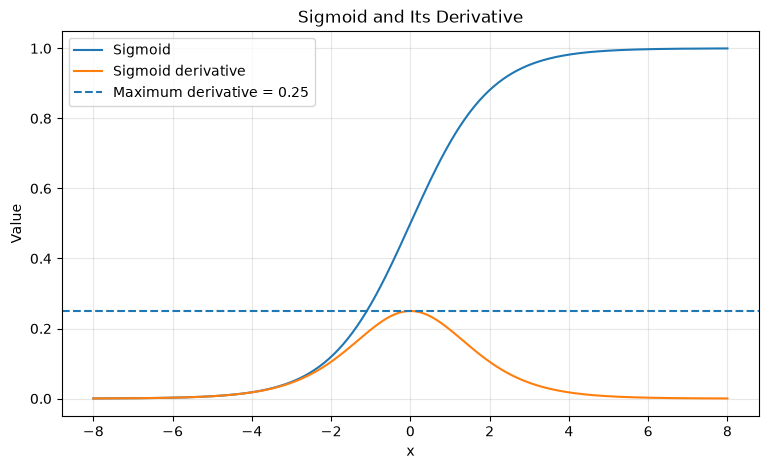

In [1]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-8, 8, 400)

sigmoid = 1 / (1 + np.exp(-x))
sigmoid_derivative = sigmoid * (1 - sigmoid)

plt.figure(figsize=(9, 5))

plt.plot(
    x,
    sigmoid,
    label="Sigmoid"
)

plt.plot(
    x,
    sigmoid_derivative,
    label="Sigmoid derivative"
)

plt.axhline(
    0.25,
    linestyle="--",
    label="Maximum derivative = 0.25"
)

plt.xlabel("x")
plt.ylabel("Value")
plt.title("Sigmoid and Its Derivative")

plt.legend()
plt.grid(True, alpha=0.3)

plt.show()


> Where is the sigmoid derivative largest?

Answer:

$$
x=0
$$

> What happens far from zero?

Answer:

> The derivative approaches zero.


This gives us the next intuition:

```text
Large |x|
   ↓
Sigmoid saturation
   ↓
Derivative ≈ 0
   ↓
Gradient becomes smaller
   ↓
Earlier layers learn very slowly
```

---

# 8. Tanh Has the Same Problem

The hyperbolic tangent is:

$$
\tanh(x)
$$

Its derivative is:

$$
\frac{d}{dx}\tanh(x)=
1-\tanh^2(x)
$$

The derivative is largest around zero and approaches zero when the neuron saturates.

x = np.linspace(-5, 5, 400)

tanh = np.tanh(x)
tanh_derivative = 1 - tanh**2

plt.figure(figsize=(9, 5))

plt.plot(
    x,
    tanh,
    label="Tanh"
)

plt.plot(
    x,
    tanh_derivative,
    label="Tanh derivative"
)

plt.xlabel("x")
plt.ylabel("Value")
plt.title("Tanh and Its Derivative")

plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

### Key Message

> **Sigmoid and Tanh do not always cause vanishing gradients, but their derivatives can become very small, and repeated multiplication through many layers makes the problem severe.**

---

# 9. ReLU: A Different Gradient Behavior — 8 min

ReLU is:

$$
f(x)=\max(0,x)
$$

Its derivative is approximately:

$$
f'(x)=
\begin{cases}
0 & x<0\
1 & x>0
\end{cases}
$$

The important difference:

```text
Sigmoid:

Derivative
   ↓
usually < 1
   ↓
repeated multiplication
   ↓
can vanish


ReLU:

Positive region
   ↓
Derivative ≈ 1
   ↓
repeated multiplication
   ↓
much less likely to vanish
```

### Visualization

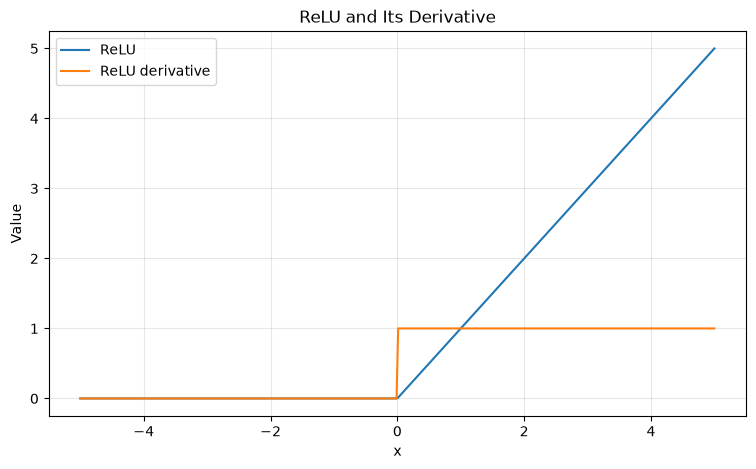

In [2]:
x = np.linspace(-5, 5, 400)

relu = np.maximum(0, x)
relu_derivative = (x > 0).astype(float)

plt.figure(figsize=(9, 5))

plt.plot(
    x,
    relu,
    label="ReLU"
)

plt.plot(
    x,
    relu_derivative,
    label="ReLU derivative"
)

plt.xlabel("x")
plt.ylabel("Value")
plt.title("ReLU and Its Derivative")

plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

---

# 10. But ReLU Has Its Own Problem

For:

$$
x<0
$$

we have:

$$
f'(x)=0
$$

So a neuron that consistently receives negative inputs can produce almost no gradient.

This leads to the **dying ReLU** problem.

Conceptually:

```text
Negative activation
        ↓
ReLU output = 0
        ↓
Derivative = 0
        ↓
Gradient through neuron = 0
        ↓
Neuron may stop learning
```

This motivates alternatives such as **Leaky ReLU**.

---

# 11. Exploding Gradients

Vanishing gradients occur when repeated factors are smaller than one.

The opposite can happen when the factors are larger than one.

For example:

$$
1.5^{10}\approx57.7
$$

and:

$$
1.5^{20}\approx3325
$$

The gradient can become extremely large.

This can cause:

* Very large parameter updates
* Unstable training
* Loss becoming `NaN`
* Numerical overflow

### Simple Visualization

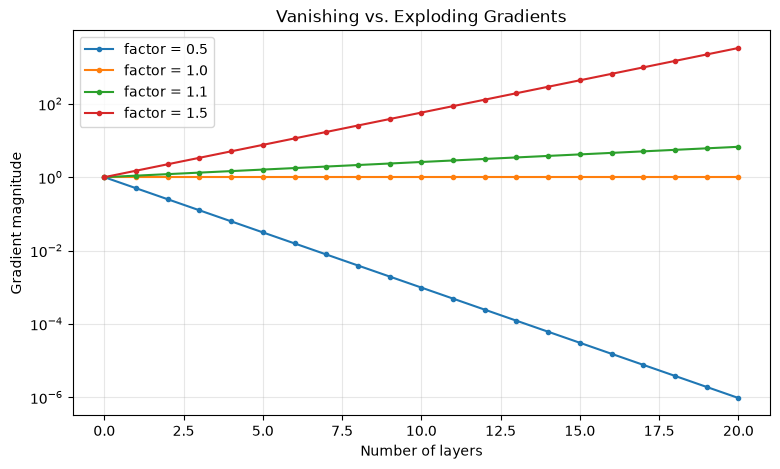

In [3]:
factors = [0.5, 1.0, 1.1, 1.5]

layers = np.arange(0, 21)

plt.figure(figsize=(9, 5))

for factor in factors:

    signal = factor ** layers

    plt.plot(
        layers,
        signal,
        marker="o",
        markersize=3,
        label=f"factor = {factor}"
    )

plt.yscale("log")

plt.xlabel("Number of layers")
plt.ylabel("Gradient magnitude")
plt.title("Vanishing vs. Exploding Gradients")

plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

---

# 12. A Real PyTorch Experiment

Now let's **measure gradients instead of just looking at equations**.

We construct deep networks with sigmoid and ReLU.

In [4]:
import torch
import torch.nn as nn


def create_network(activation, depth=10):

    layers = []

    layers.append(nn.Linear(20, 50))

    for _ in range(depth - 1):

        layers.append(activation)
        layers.append(nn.Linear(50, 50))

    layers.append(activation)
    layers.append(nn.Linear(50, 1))

    return nn.Sequential(*layers)

In [5]:
# Create two networks
sigmoid_net = create_network(nn.Sigmoid(), depth=10)
relu_net = create_network(nn.ReLU(), depth=10)


# Same input
x = torch.randn(32, 20)
target = torch.randn(32, 1)

criterion = nn.MSELoss()


def inspect_gradients(model):

    output = model(x)
    loss = criterion(output, target)

    loss.backward()

    print(f"Loss: {loss.item():.4f}")

    for name, parameter in model.named_parameters():

        if parameter.grad is not None:

            print(
                f"{name:20s} "
                f"gradient mean = "
                f"{parameter.grad.abs().mean().item():.8f}"
            )


print("===== SIGMOID NETWORK =====")

inspect_gradients(sigmoid_net)


# Clear gradients
sigmoid_net.zero_grad()


print("\n===== RELU NETWORK =====")

inspect_gradients(relu_net)

===== SIGMOID NETWORK =====
Loss: 0.8082
0.weight             gradient mean = 0.00000000
0.bias               gradient mean = 0.00000000
2.weight             gradient mean = 0.00000000
2.bias               gradient mean = 0.00000000
4.weight             gradient mean = 0.00000000
4.bias               gradient mean = 0.00000000
6.weight             gradient mean = 0.00000001
6.bias               gradient mean = 0.00000002
8.weight             gradient mean = 0.00000006
8.bias               gradient mean = 0.00000012
10.weight            gradient mean = 0.00000044
10.bias              gradient mean = 0.00000088
12.weight            gradient mean = 0.00000322
12.bias              gradient mean = 0.00000629
14.weight            gradient mean = 0.00002543
14.bias              gradient mean = 0.00005052
16.weight            gradient mean = 0.00016836
16.bias              gradient mean = 0.00032521
18.weight            gradient mean = 0.00138956
18.bias              gradient mean = 0.00284893

### Ask Students

Look at the gradients of:

```text
first layer
      vs.
last layer
```

> Are the gradients equally large throughout the network?

answer:

> No. In a deep network, gradient magnitude can change dramatically from layer to layer.

---

# 13. Gradient Clipping

A common technique for exploding gradients is **gradient clipping**.

Suppose:

$$
||\mathbf g||=100
$$

but we allow a maximum norm of:

$$
c=5
$$

We rescale the gradient:

$$
\mathbf g
\leftarrow
c
\frac{\mathbf g}{||\mathbf g||}
$$

So the new gradient has norm:

$$
||\mathbf g||=5
$$

In PyTorch:

```python
torch.nn.utils.clip_grad_norm_(
    model.parameters(),
    max_norm=1.0
)
```

The important intuition is:

> **Gradient clipping does not solve why the gradient exploded. It prevents an excessively large gradient from producing an excessively large update.**

---

# 14. The Big Picture

At this point students should be able to connect all the concepts:

```text
                 Deep Network
                      │
                      ▼
                Backpropagation
                      │
                      ▼
              Repeated multiplication
                      │
             ┌────────┴────────┐
             │                 │
        Factors < 1        Factors > 1
             │                 │
             ▼                 ▼
        Vanishing           Exploding
        Gradient             Gradient
             │                 │
             ▼                 ▼
       Early layers        Unstable
       learn slowly        training
```

---

# 15. How Do We Fix These Problems?

Do **not** go deeply into the solutions yet. That is the topic of the next session.

We only only the roadmap:

| Problem                | Main idea                                                              |
| ---------------------- | ---------------------------------------------------------------------- |
| Vanishing gradients    | Use activations and initialization that preserve gradient flow         |
| Exploding gradients    | Control parameter scale and, when needed, clip gradients               |
| Saturating activations | Prefer activations such as ReLU-family functions in many deep networks |
| Poor initialization    | Choose initialization appropriate to the activation                    |

> **Next session we will ask: how can we design a network so that gradients survive the journey through many layers?**

This creates a natural transition to **ReLU, Leaky ReLU, Xavier initialization, and He initialization**.

---

# 16. Classroom Exercise

Give students the following scenario:

A network has 20 layers.

Assume that, approximately, every layer multiplies the gradient by $0.8$.

### Question 1

Estimate the gradient after 20 layers:

$$
0.8^{20}
$$

### Question 2

Now suppose every layer multiplies the gradient by $1.2$:

$$
1.2^{20}
$$

### Question 3

Which situation is more dangerous?

### Expected Results

$$
0.8^{20}\approx0.0115
$$

So the gradient has become very small.

And:

$$
1.2^{20}\approx38.34
$$

So the gradient has become very large.

### Final Discussion

Ask:

> **What matters more: the gradient at the output layer or the gradient that reaches the early layers?**

Expected answer:

> Both matter, but if the gradient reaching early layers is extremely small, those layers may learn very slowly.

---

# 17. Final Takeaway

Students should leave the session with these four ideas:

### 1. Backpropagation is a chain of multiplications

$$
\text{Gradient}
\approx
\text{many local derivatives multiplied together}
$$

### 2. Small factors accumulate

$$
0.5\times0.5\times0.5\times\cdots
\rightarrow 0
$$

This creates **vanishing gradients**.

### 3. Large factors accumulate

$$
1.5\times1.5\times1.5\times\cdots
\rightarrow \text{very large}
$$

This creates **exploding gradients**.

### 4. The central problem of deep learning

> **How can we make the gradient survive as it travels through many layers?**

That question motivates the next session:

$$
\boxed{
\text{Activations}
+
\text{Weight Initialization}
\rightarrow
\text{Better Gradient Flow}
}
$$

---

# Suggested Teaching Visualization Sequence

For the actual presentation, use the following visual progression:

```text
1. Simple 3-layer network
        ↓
2. Gradient flowing backward
        ↓
3. Chain Rule
        ↓
4. 0.5 × 0.5 × 0.5 × ...
        ↓
5. Vanishing gradient curve
        ↓
6. Sigmoid derivative
        ↓
7. Repeated sigmoid layers
        ↓
8. 1.5 × 1.5 × 1.5 × ...
        ↓
9. Exploding gradient curve
        ↓
10. PyTorch measurement
        ↓
11. Gradient clipping
        ↓
12. "How do we fix it?"
```

The pedagogical goal is that students **discover the problem before learning the solutions**. The key mental model should be:

> **A gradient is a signal traveling backward through the network. Depth means the signal must pass through many transformations. If those transformations systematically shrink the signal, it vanishes; if they amplify it, it explodes.**